In [ ]:
import pandas as pd

amazon = pd.read_csv(
    "sentiment labelled sentences/amazon_cells_labelled.txt",
    sep="\t",
    names=["Review", "Sentiment"]
)

imdb = pd.read_csv(
    "sentiment labelled sentences/imdb_labelled.txt",
    sep="\t",
    names=["Review", "Sentiment"]
)

yelp = pd.read_csv(
    "sentiment labelled sentences/yelp_labelled.txt",
    sep="\t",
    names=["Review", "Sentiment"]
)

df = pd.concat([amazon, imdb, yelp], ignore_index=True)

print(df.head())
print(df.shape)

                                              Review  Sentiment
0  So there is no way for me to plug it in here i...          0
1                        Good case, Excellent value.          1
2                             Great for the jawbone.          1
3  Tied to charger for conversations lasting more...          0
4                                  The mic is great.          1
(2748, 2)


In [3]:
df.to_csv("customer_feedback_sentiment.csv", index=False)

print("CSV file created successfully")

CSV file created successfully


In [15]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df = df.drop_duplicates()
df = df.dropna()

df["Cleaned_Review"] = df["Review"].apply(clean_text)

df["Sentiment_Label"] = df["Sentiment"].map({
    0: "Negative",
    1: "Positive"
})

# Put it here
df["Cleaned_Review"] = df["Cleaned_Review"].fillna("").astype(str)

# Then save the cleaned file
df.to_csv("cleaned_feedback_data.csv", index=False)

print("Cleaned CSV created successfully")

Cleaned CSV created successfully


In [4]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df = df.drop_duplicates()
df = df.dropna()

df["Cleaned_Review"] = df["Review"].apply(clean_text)

df["Sentiment_Label"] = df["Sentiment"].map({
    0: "Negative",
    1: "Positive"
})

df.to_csv("cleaned_feedback_data.csv", index=False)

print("Cleaned CSV created successfully")

Cleaned CSV created successfully


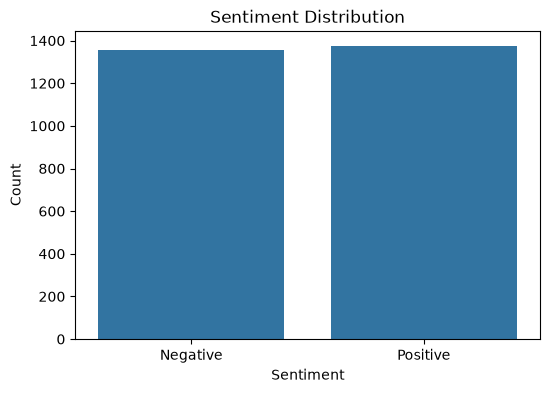

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Sentiment_Label")
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

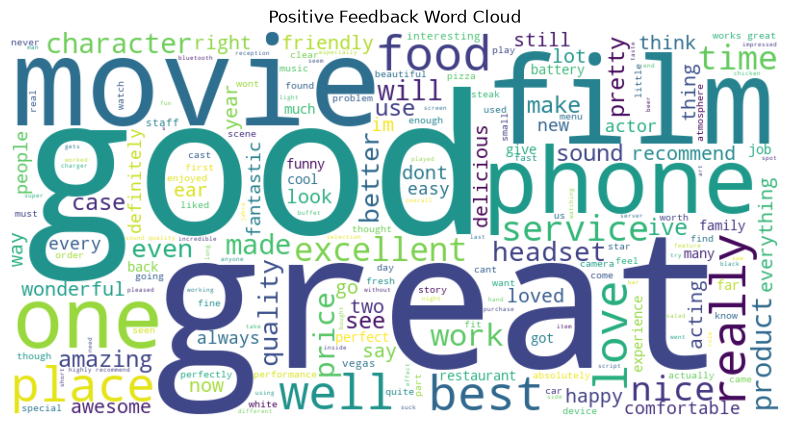

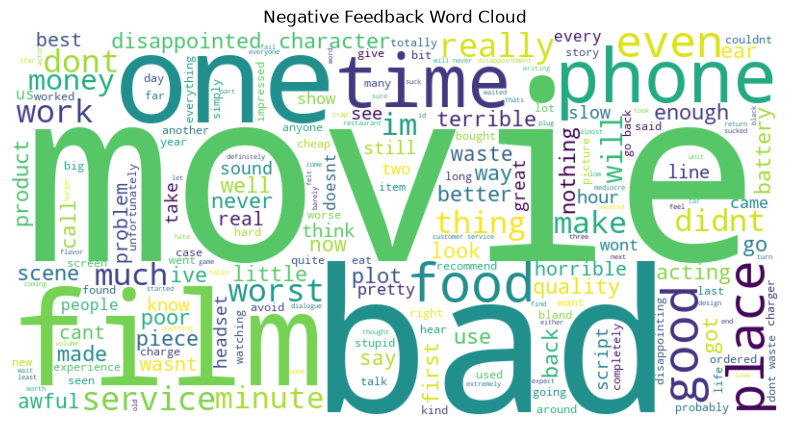

In [16]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

positive_reviews = df[df["Sentiment"] == 1]["Cleaned_Review"].dropna().astype(str)
negative_reviews = df[df["Sentiment"] == 0]["Cleaned_Review"].dropna().astype(str)

positive_text = " ".join(positive_reviews)
negative_text = " ".join(negative_reviews)

if positive_text.strip() != "":
    plt.figure(figsize=(10, 5))
    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color="white"
    ).generate(positive_text)

    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title("Positive Feedback Word Cloud")
    plt.show()
else:
    print("No positive text available for word cloud.")

if negative_text.strip() != "":
    plt.figure(figsize=(10, 5))
    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color="white"
    ).generate(negative_text)

    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title("Negative Feedback Word Cloud")
    plt.show()
else:
    print("No negative text available for word cloud.")

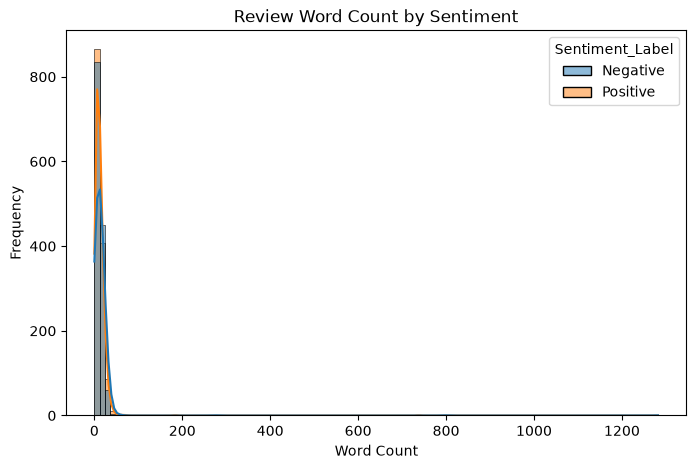

In [9]:
df["Review_Length"] = df["Cleaned_Review"].apply(len)
df["Word_Count"] = df["Cleaned_Review"].apply(lambda x: len(x.split()))

plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="Word_Count", hue="Sentiment_Label", kde=True)
plt.title("Review Word Count by Sentiment")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.show()

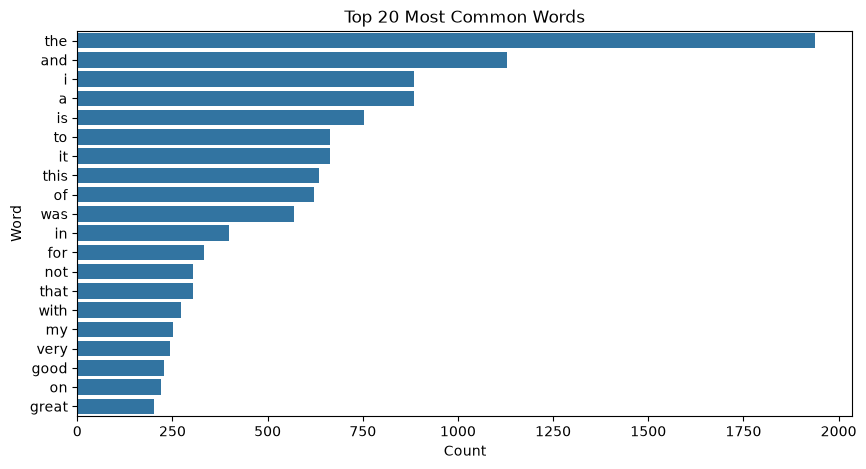

In [10]:
from collections import Counter

all_words = " ".join(df["Cleaned_Review"]).split()
word_freq = Counter(all_words).most_common(20)

word_df = pd.DataFrame(word_freq, columns=["Word", "Count"])

plt.figure(figsize=(10, 5))
sns.barplot(data=word_df, x="Count", y="Word")
plt.title("Top 20 Most Common Words")
plt.show()

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib

X = df["Cleaned_Review"]
y = df["Sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

vectorizer = TfidfVectorizer(stop_words="english", max_features=5000)

X_train_vectorized = vectorizer.fit_transform(X_train)
X_test_vectorized = vectorizer.transform(X_test)

model = LogisticRegression()
model.fit(X_train_vectorized, y_train)

y_pred = model.predict(X_test_vectorized)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7915904936014625
              precision    recall  f1-score   support

           0       0.77      0.81      0.79       270
           1       0.81      0.77      0.79       277

    accuracy                           0.79       547
   macro avg       0.79      0.79      0.79       547
weighted avg       0.79      0.79      0.79       547



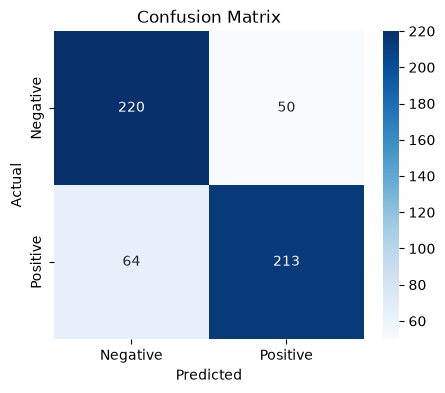

In [12]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Negative", "Positive"],
            yticklabels=["Negative", "Positive"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [13]:
joblib.dump(model, "sentiment_model.pkl")
joblib.dump(vectorizer, "tfidf_vectorizer.pkl")

print("Model and vectorizer saved successfully")

Model and vectorizer saved successfully


In [14]:
sample_review = ["The product quality is excellent and I loved it"]

sample_cleaned = [clean_text(sample_review[0])]
sample_vectorized = vectorizer.transform(sample_cleaned)

prediction = model.predict(sample_vectorized)[0]

if prediction == 1:
    print("Positive Feedback")
else:
    print("Negative Feedback")

Positive Feedback
